In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from astropy.io import fits
import matplotlib
from scipy import interpolate
import pickle
import glob

import lsd_utils as lsd
homedir = os.path.expanduser("~")
datadir = f"{homedir}/uoedrive/data/gcm_hires/w1049b-sept2025"
c_km_s = 3e5

In [2]:
m_orders = [
    [4.41, 4.47],
    [4.47, 4.54],
    [4.56, 4.63],
    [4.68, 4.75],
    [4.77, 4.84],
    [4.86, 4.93],
]
m_orders = [
    [4.5541, 4.6256],
    [4.6713, 4.7472],
    [4.7625, 4.8371],
    [4.8589, 4.9383]
]
goodchips = [0,1,2,3]
nchip = len(goodchips)

In [3]:
wl_sum = 0
for i in m_orders:
    wl_sum += i[1]-i[0]
wl_sum

0.301400000000001

Read GCM data and fitted models

In [4]:
target = 'case1'
bestmodelname = 't1400g1000f2'
resultdir = f"{homedir}/uoedrive/result/fitted/diamondback"

with open(f'{resultdir}/METIS_{target}_M_{bestmodelname}.pickle', 'rb') as f:
    data = pickle.load(f)
res = np.loadtxt(f'{resultdir}/METIS_{target}_M_fitting_results_{bestmodelname}.txt', skiprows=1)
order, obs, chisq, vsini, lld, rv = res.T
rvs = np.nanmedian(rv.reshape(len(m_orders),20), axis=1)
rvs

array([3.835e-08, 2.380e-06, 2.360e-06, 1.445e-06])

Read METIS mock spectra

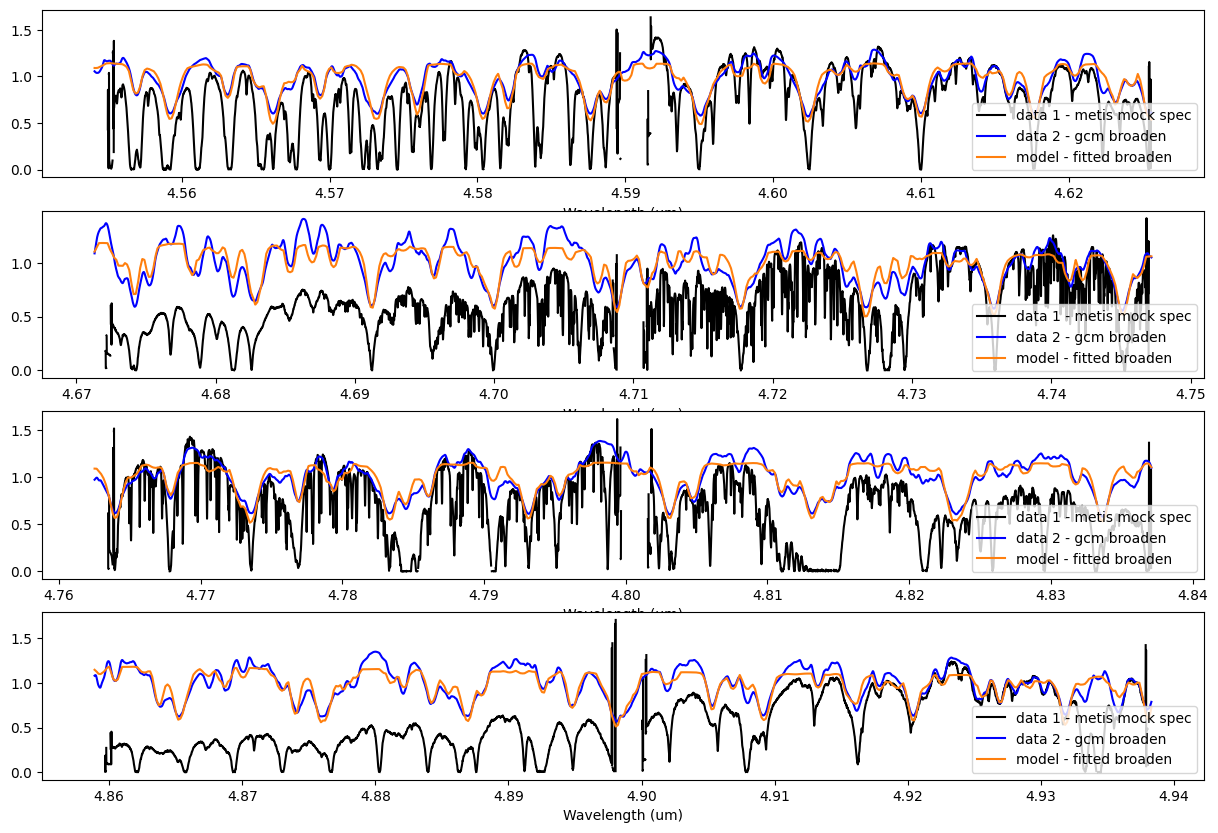

In [5]:
target = 'case1'
bestmodelname = 't1400g1000f2'
metisdir = f"{homedir}/workspace/metis-sim/output/"

metis = []
for c in [2,3,4,5]:
    with open(f'{metisdir}/METIS_{target}_M{c}_gcm_300x3.pickle', 'rb') as f:
        metis.append(pickle.load(f))
t=0
if target == 'case1':
    scale_ref = [50000, 45000, 46000, 36000]
elif target == 'case2':
    scale_ref = [13000, 11200, 11500, 9000]
elif target == 'case3':
    scale_ref = [3200, 2800, 2900, 2200]
plt.figure(figsize=(15,10))
for i, c in enumerate([2,3,4,5]):
    plt.subplot(4, 1, i+1)
    plt.plot(metis[i]['chiplams'][t,0], metis[i]['observed'][t,0]/scale_ref[i], color='k', label=f'data 1 - metis mock spec')
    plt.plot(data['chiplams'][t,i], data['observed'][t,i], color='b', label=f'data 2 - gcm broaden')
    plt.plot(data["chiplams"][t,i], data['chipmods'][t,i], color='tab:orange', label=f'model - fitted broaden')
    #plt.plot(metis['chiplams'][t,cm]*(1-shift), metis['chipmods'][t,cm]/scale_ref, color='orange', label=f'model - metis mock spec')
    plt.xlabel('Wavelength (um)')
    plt.legend(loc='lower right');

In [6]:
# Interpolate to same wavelength grid
nobs=20
nchip=4
npix=4000
NDIT = 3
if target == "case3":
    NDIT = 6
chiplams = np.empty((nobs, nchip, npix), dtype=np.float32)
observed = np.empty((nobs, nchip, npix), dtype=np.float32)
template = np.empty((nobs, nchip, npix), dtype=np.float32)
mock_observed = np.empty((nobs, nchip, npix), dtype=np.float32)
error = np.empty((nobs, nchip, npix), dtype=np.float32)
for i, c in enumerate(goodchips):
    wlmin = max(data['chiplams'][0,i,0], metis[i]['chiplams'][0,0,0])
    wlmax = min(data['chiplams'][0,i,-1], metis[i]['chiplams'][0,0,-1])
    print('chip:', i, "wlmin:", wlmin, "wlmax:", wlmax)
    for t in range(nobs):
        lams_lin = np.linspace(wlmin, wlmax, npix, dtype=np.float32)
        spline_observed = interpolate.interp1d(data['chiplams'][t,i], data['observed'][t,i], kind='linear', bounds_error=False, fill_value='extrapolate')
        spline_chipmodnobroad = interpolate.interp1d(data['chiplams'][t,i], data['chipmodnobroad'][t,i], kind='linear', bounds_error=False, fill_value='extrapolate')
        spline_error = interpolate.interp1d(metis[i]['chiplams'][t,0], metis[i]['error'][t,0], kind='linear', bounds_error=False, fill_value='extrapolate')
        chiplams[t,i] = lams_lin
        observed[t,i] = spline_observed(lams_lin)
        template[t,i] = spline_chipmodnobroad(lams_lin)
        error[t,i] = spline_error(lams_lin)

        # add noise
        noise = np.random.normal(0, error[t,i]*np.sqrt(NDIT))
        mock_observed[t,i] = observed[t,i]*scale_ref[i]*NDIT + np.nan_to_num(noise, nan=0.0)
        mock_observed[t,i] /= np.nanmedian(mock_observed[t,i])

        #spline_metisobserved = interpolate.interp1d(metis[i]['chiplams'][t,0], metis[i]['observed'][t,0], kind='linear', bounds_error=False, fill_value='extrapolate')
        #mock_observed[t,i] = spline_metisobserved(lams_lin)/np.nanmedian(spline_metisobserved(lams_lin))

chip: 0 wlmin: 4.554103371627004 wlmax: 4.625593404476478
chip: 1 wlmin: 4.67131523211993 wlmax: 4.747189062057629
chip: 2 wlmin: 4.762518697238886 wlmax: 4.837086933977529
chip: 3 wlmin: 4.858902873902749 wlmax: 4.938297649340413


SNR = 193.3 for chip 2
SNR = 208.7 for chip 3
SNR = 176.5 for chip 4
SNR = 161.2 for chip 5
SNR average: 184.92941021816222


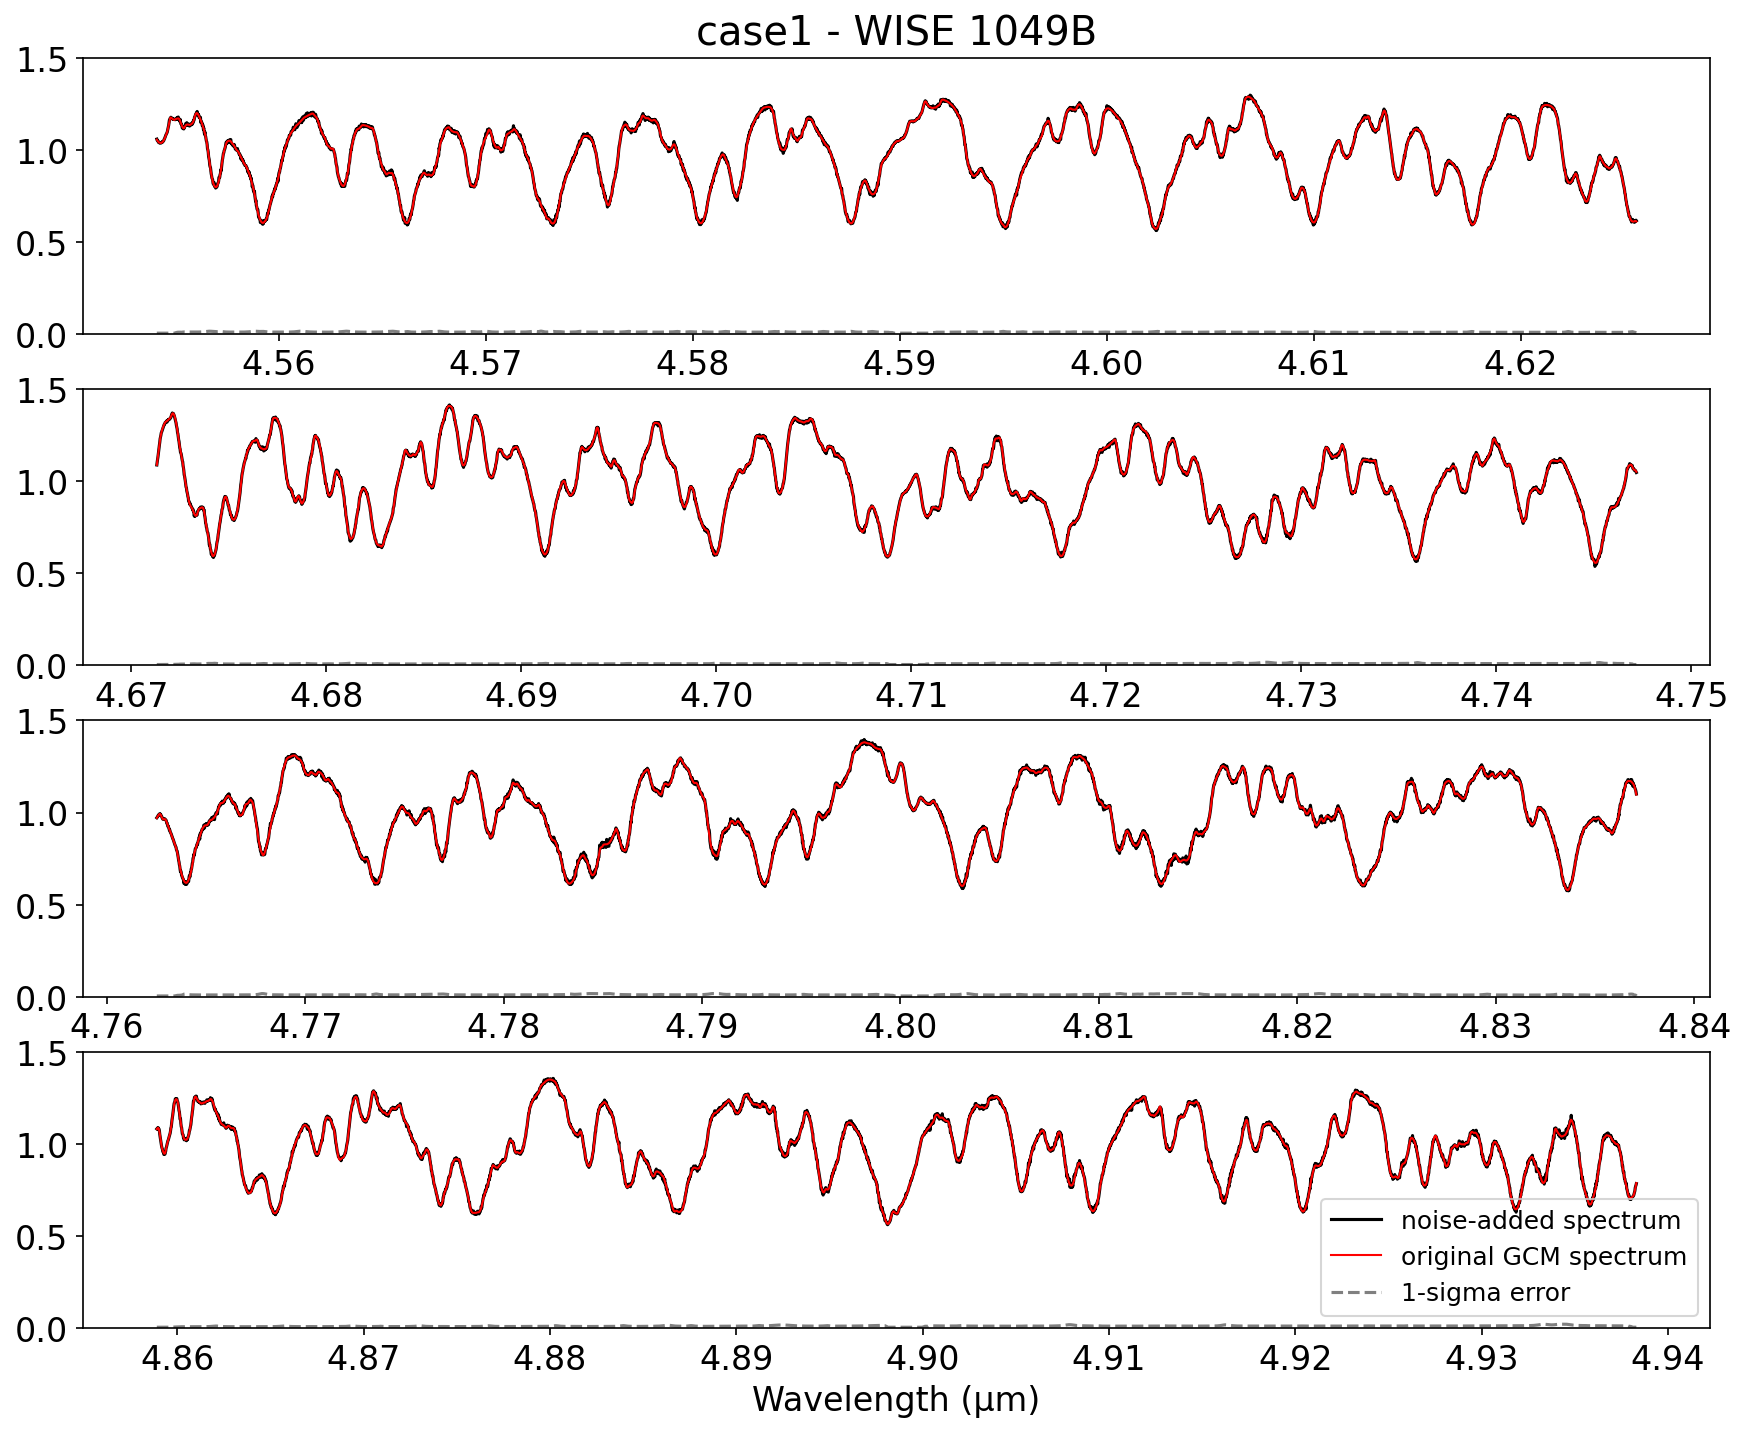

In [7]:
# WhiteBG mockspec plot
targetname = {'case1': 'WISE 1049B', 'case2': 'Eps Ind Ba', 'case3': 'beta Pic b'}

with plt.rc_context({
    'font.size': 16,
    'axes.facecolor': 'none',
    'figure.facecolor': 'none',
}):
    plt.figure(figsize=(14,11), dpi=150)
    snr_chip = np.empty(nchip)
    for i, c in enumerate([2,3,4,5]):
        plt.subplot(4, 1, i+1)
        if i == 0:
            plt.title(f'{target} - {targetname[target]}')
        plt.ylim(0, 1.5)
        plt.yticks([0,0.5,1,1.5])
        plt.plot(chiplams[0,i], mock_observed[0,i], color='k', label=f'noise-added spectrum')
        plt.plot(chiplams[0,i], observed[0,i], color='r', lw=1,label=f'original GCM spectrum')
        plt.plot(chiplams[0,i], error[0,i]/scale_ref[i], '--', color='gray', label=f'1-sigma error')
        #plt.plot(chiplams[0,i], template[0,i], color='tab:orange', label=f'Diamondback model')
        snr_chip[i] = np.sqrt(NDIT)*scale_ref[i]/np.median(error[0,i])
        print(f"SNR = {snr_chip[i]:.1f} for chip {c}")
    plt.xlabel('Wavelength (μm)')
    plt.legend(loc='lower right', fontsize=12)
    print("SNR average:", np.mean(snr_chip))

SNR = 193.3 for chip 2
SNR = 208.7 for chip 3
SNR = 176.5 for chip 4
SNR = 161.2 for chip 5
SNR average: 184.92941021816222


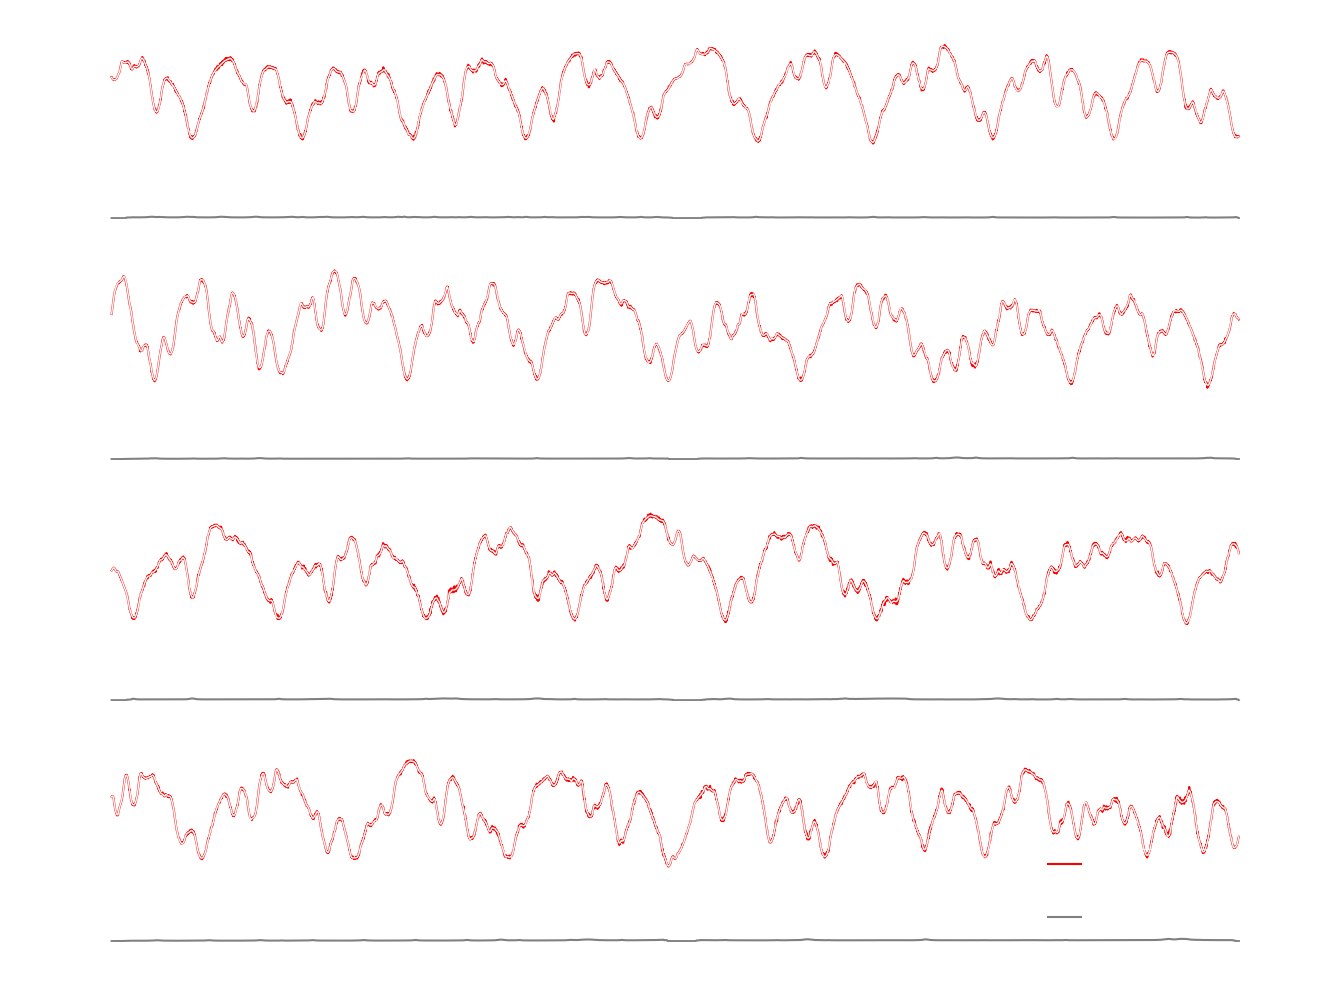

In [8]:
with plt.rc_context({
    'font.size': 16,
    'axes.facecolor': 'none',
    'figure.facecolor': 'none',
    'axes.edgecolor': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'text.color': 'white',
    'legend.facecolor': 'none',
    'legend.edgecolor': 'white',
}):
    plt.figure(figsize=(16,12))
    snr_chip = np.empty(nchip)
    for i, c in enumerate([2,3,4,5]):
        plt.subplot(4, 1, i+1)
        plt.ylim(0, 1.5)
        plt.yticks([0,0.5,1,1.5])
        plt.plot(chiplams[0,i], mock_observed[0,i], color='r', label=f'noise-added spectrum')
        plt.plot(chiplams[0,i], observed[0,i], color='w', lw=1,label=f'original spectrum')
        plt.plot(chiplams[0,i], error[0,i]/scale_ref[i], color='gray', label=f'error')
        #plt.plot(chiplams[0,i], template[0,i], color='tab:orange', label=f'Diamondback model')
        snr_chip[i] = np.sqrt(NDIT)*scale_ref[i]/np.median(error[0,i])
        print(f"SNR = {snr_chip[i]:.1f} for chip {c}")
    plt.xlabel('Wavelength (um)')
    plt.legend(loc='lower right', fontsize=12);
print("SNR average:", np.mean(snr_chip))

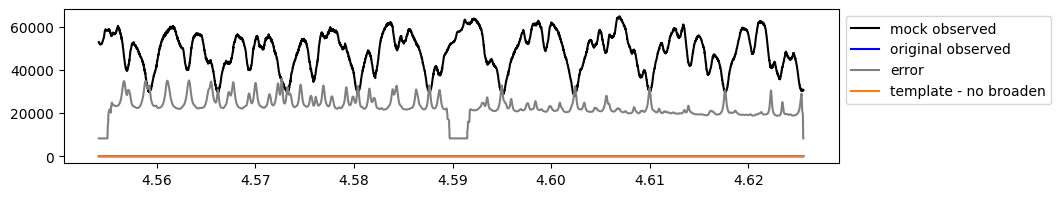

In [9]:
plt.figure(figsize=(10,2))
plt.plot(chiplams[0,0], mock_observed[0,0]*scale_ref[0], color='k', label=f'mock observed')
plt.plot(chiplams[0,0], observed[0,0], color='b', label=f'original observed')
plt.plot(chiplams[0,0], error[0,0]*50, color='gray', label=f'error')
plt.plot(chiplams[0,0], template[0,0], color='tab:orange', label=f'template - no broaden')
plt.legend(loc=2, bbox_to_anchor=(1, 1));

In [10]:
# --- Equivalent width integration ---
def equivalent_width(wave, flux):
    # assumes flux normalized to continuum = 1
    return np.trapz(1 - flux, wave)

# --- Upper-envelope continuum fit ---
def fit_continuum_upper_envelope(wave, flux, order=5, segment_width=50, percentile=95):
    """
    Fit a smooth polynomial continuum approximating the upper envelope.
    """
    n = len(wave)
    segs = np.arange(0, n, segment_width)
    upper_x, upper_y = [], []

    for i in segs:
        j = min(i + segment_width, n)
        upper_x.append(np.median(wave[i:j]))
        upper_y.append(np.percentile(flux[i:j], percentile))

    coeffs = np.polyfit(upper_x, upper_y, order)
    continuum = np.polyval(coeffs, wave)
    return continuum

# --- Slope-change-based line detection ---
def detect_lines(
    wave, flux, continuum_order=5,
    depth_threshold=0.05, window=5
):
    """
    Detect absorption lines where the flux slope changes from negative to positive.

    Parameters
    ----------
    wave : ndarray
        Wavelength array (Å)
    flux : ndarray
        Observed flux array
    depth_threshold : float
        Minimum drop below continuum (e.g. 0.01 = 1%)
    window : int
        Half-width (pixels) for local EW integration
    """

    # --- Fit continuum and normalize ---
    continuum = fit_continuum_upper_envelope(
        wave, flux, order=continuum_order,
        segment_width=50, percentile=95
    )
    norm_flux = flux / continuum

    # --- Compute numerical derivative ---
    dflux = np.diff(norm_flux)

    centers, ews = [], []

    # --- Detect slope sign reversals (decreasing → increasing) ---
    for i in range(1, len(dflux)):
        if dflux[i-1] < 0 and dflux[i] > 0:
            # candidate local minimum at i
            # check depth threshold
            if (1 - norm_flux[i]) > depth_threshold:
                i1, i2 = max(i - window, 0), min(i + window, len(wave) - 1)
                x, y = wave[i1:i2], norm_flux[i1:i2]
                ew = equivalent_width(x, y)
                centers.append(wave[i])
                ews.append(ew)

    # --- Filter nonphysical EWs ---
    centers = np.array(centers)
    ews = np.array(ews)
    mask = ews > 1e-4
    centers = centers[mask]
    ews = ews[mask]

    return continuum, centers, ews


In [11]:
# prepare wl for line search
wlmin = m_orders[0][0]
wlmax = m_orders[-1][1]
print(wlmin, wlmax)
wlstep = 0.5*1e-4
wl_lin = np.arange(wlmin, wlmax+wlstep, wlstep, dtype=np.float32)
wl_lin_ang = wl_lin * 1e4  # in micron

# prepare spectrum for line search
spec_all = []
wl = np.loadtxt(f"{homedir}/uoedrive/data/gcm_hires/w1049b-sept2025/high-resolution/wavelength_micron.txt")
for t in range(20):
    spec = np.loadtxt(f"{homedir}/uoedrive/data/gcm_hires/w1049b-sept2025/high-resolution/spectrum_erg.s.cm3_nobroaden_time{t+1}.txt")
    spec_all.append(spec)
spec_all = np.array(spec_all)
spec_mean = np.nanmedian(spec_all,axis=0)
interp_func = interpolate.interp1d(wl, spec_mean, kind='linear', bounds_error=False, fill_value=0.0)
spec_lin = interp_func(wl_lin)

# find lines
my_cont, my_lineloc, my_lineew = detect_lines(wl_lin_ang, spec_lin, window=4, depth_threshold=0.05)
my_lineloc.shape, my_lineew.shape, my_lineew.min(), my_lineew.max(), my_lineew.mean()

4.5541 4.9383


/var/folders/jm/dmx123p56254c5gy18wgtyh00000gn/T/ipykernel_21286/752337981.py:45: RankWarning: Polyfit may be poorly conditioned
  continuum = fit_continuum_upper_envelope(


((978,), (978,), 0.0016113739732927304, 2.0475914602640564, 0.7958134187242745)

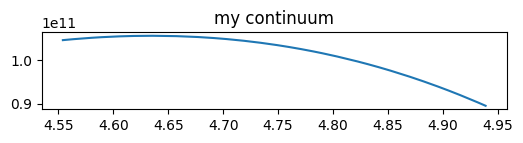

In [12]:
# plot continuum
plt.figure(figsize=(6,1))
plt.plot(wl_lin, my_cont)
plt.title("my continuum")
my_spline = interpolate.UnivariateSpline(wl_lin, my_cont, s=0.0, k=1.0)

In [13]:
# Compute LSD velocity grid:
nk=150
#pad=50
wav_angs = chiplams[0] * 1e4
dbeta = np.diff(wav_angs).mean()/wav_angs.mean()
dx = dbeta * np.arange(np.floor(-nk/2.+.5), np.floor(nk/2.+.5))
dv = c_km_s*dx # km/s
npix = chiplams.shape[2]
print("dv:", dv.shape)
#print(dv)

dv: (150,)


chip 0 45541.035 46255.934 -5166103017521152.0
chip 1 46713.152 47471.89 -5300514857590784.0
chip 2 47625.188 48370.87 -5402447229509632.0
chip 3 48589.03 49382.977 -5513662370463744.0


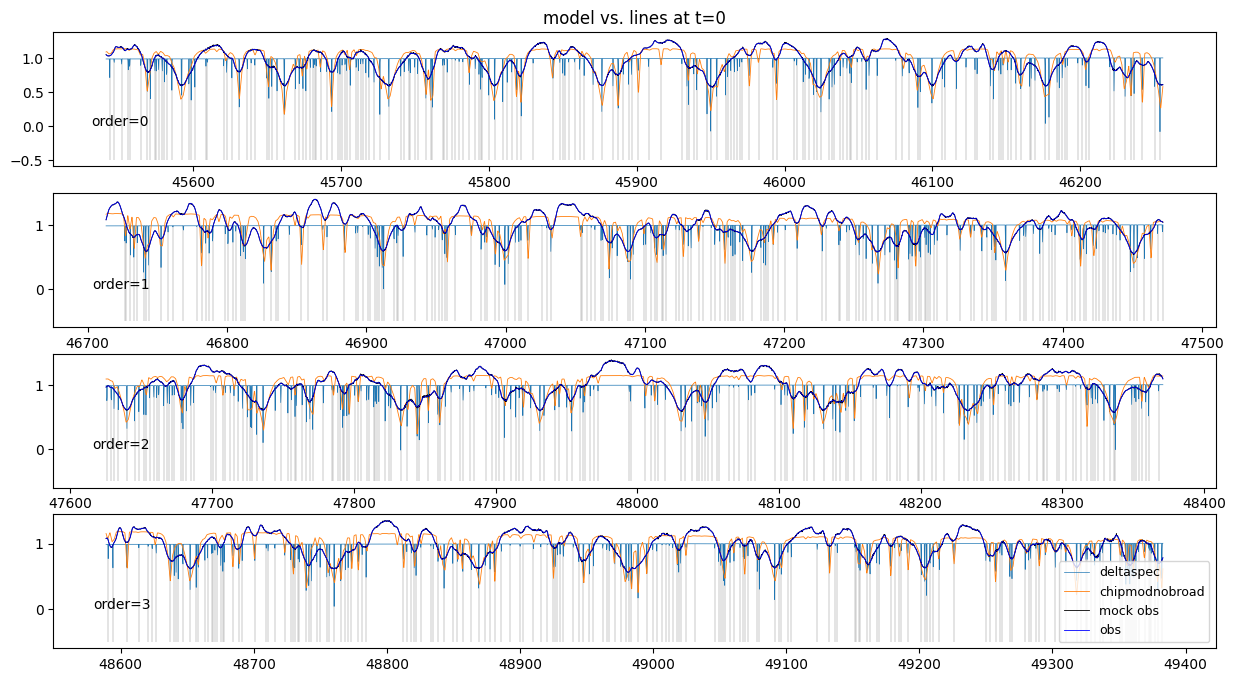

In [14]:
# Check line matching
rv_lsd = [-15e-5]
rv_lsd = [0, 0, 0, 0]

# mock compute LSD:
deltaspecs = np.zeros((nobs, nchip, npix), dtype=float)
for c in range(nchip): 
    cont = my_spline(wav_angs[c])
    print("chip", c, wav_angs[c].min(), wav_angs[c].max(), np.nanmedian(cont))
    cont /= np.nanmedian(cont)
    for t in range(nobs):
        shift = 1. + rv_lsd[c]  # best rv shift for Callie is 9e-5
        deltaspec = lsd.make_deltaspec(my_lineloc*shift, my_lineew/10, wav_angs[c], verbose=False, cont=cont)
        #_,kerns[t,c],_,_ = lsd.dsa(deltaspec, observed[t,c], nk)
        #_,modkerns[t,c],_,_ = lsd.dsa(deltaspec, template[t,c], nk) 
        deltaspecs[t,c] = deltaspec #/np.abs(np.nanmin(deltaspec))

# plot lines vs. model
plt.figure(figsize=(15, 2*nchip))
t=0
for c in range(nchip):
    plt.subplot(nchip,1,c+1)
    ind = np.where((my_lineloc>=wav_angs[c].min()) & (my_lineloc<=wav_angs[c].max()))
    plt.vlines(my_lineloc[ind], ymin=-0.5, ymax=1, color='gray', lw=0.3)
    plt.plot(wav_angs[c], deltaspecs[t,c], linewidth=0.5, color='C0', label="deltaspec")
    plt.plot(wav_angs[c], template[t,c], linewidth=0.6, color='C1', label="chipmodnobroad")
    plt.plot(wav_angs[c], mock_observed[t,c], linewidth=0.6, color='k', label="mock obs")
    plt.plot(wav_angs[c], observed[t,c], linewidth=0.6, color='b', label="obs")
    plt.text(x=wav_angs[c].min()-10, y=0, s=f"order={c}")
    if c==0:
        plt.title(f"model vs. lines at t={t}")
plt.legend(loc=4, fontsize=9)

chip 0
chip 1
chip 2
chip 3


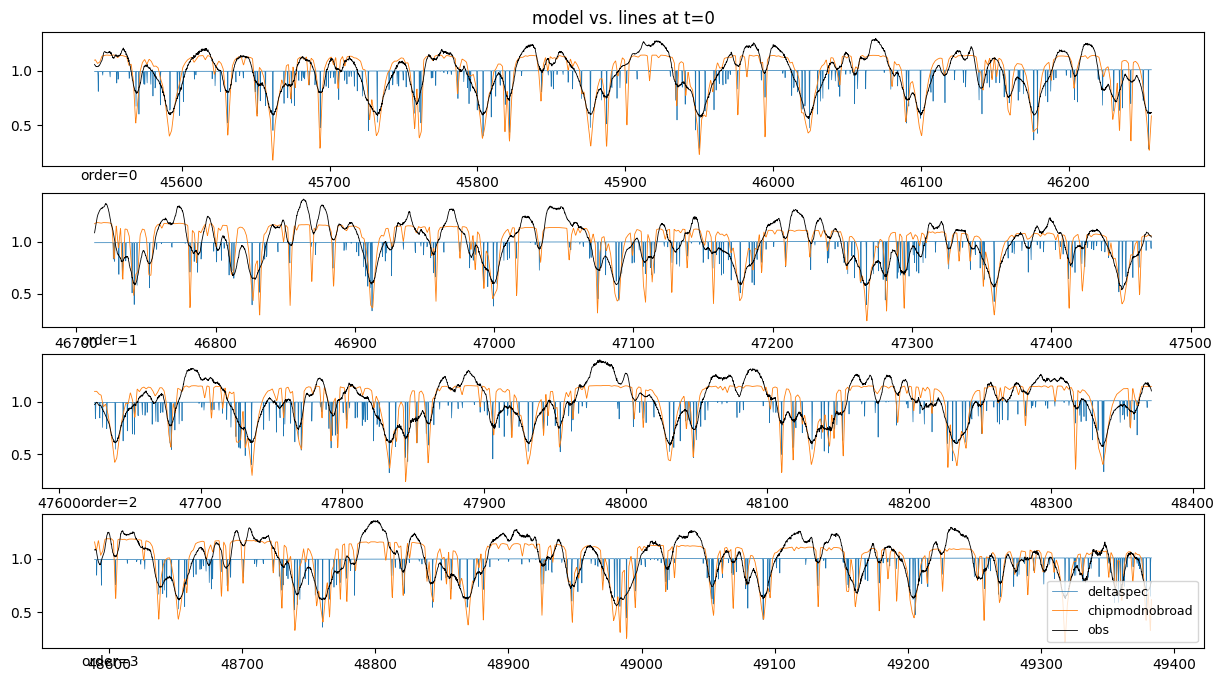

In [15]:
# Compute LSD for real
rv_lsd = [0, 0, 0, 0]

kerns = np.zeros((nobs, nchip, nk), dtype=float)
modkerns = np.zeros((nobs, nchip, nk), dtype=float)
deltaspecs = np.zeros((nobs, nchip, npix), dtype=float)
for c in range(nchip): 
    print("chip", c)
    for t in range(nobs):
        shift = 1. + rv_lsd[c]  # best rv shift for Callie is 9e-5
        cont = my_spline(wav_angs[c])
        cont /= np.nanmedian(cont)
        deltaspec = lsd.make_deltaspec(my_lineloc*shift, my_lineew/15, wav_angs[c], verbose=False, cont=cont)
    
        _,kerns[t,c],_,_ = lsd.dsa(deltaspec, mock_observed[t,c], nk)
        _,modkerns[t,c],_,_ = lsd.dsa(deltaspec, template[t,c], nk) 
        deltaspecs[t,c] = deltaspec #/np.abs(np.nanmin(deltaspec))

plt.figure(figsize=(15, 2*nchip))
t=0
for c in range(nchip):
    plt.subplot(nchip,1,c+1)
    plt.plot(wav_angs[c], deltaspecs[t,c], linewidth=0.5, color='C0', label="deltaspec")
    plt.plot(wav_angs[c], template[t,c], linewidth=0.6, color='C1', label="chipmodnobroad")
    plt.plot(wav_angs[c], mock_observed[t,c], linewidth=0.6, color='k', label="obs")
    plt.text(x=wav_angs[c].min()-10, y=0, s=f"order={c}")
    if c==0:
        plt.title(f"model vs. lines at t={t}")
plt.legend(loc=4, fontsize=9)
plt.show()

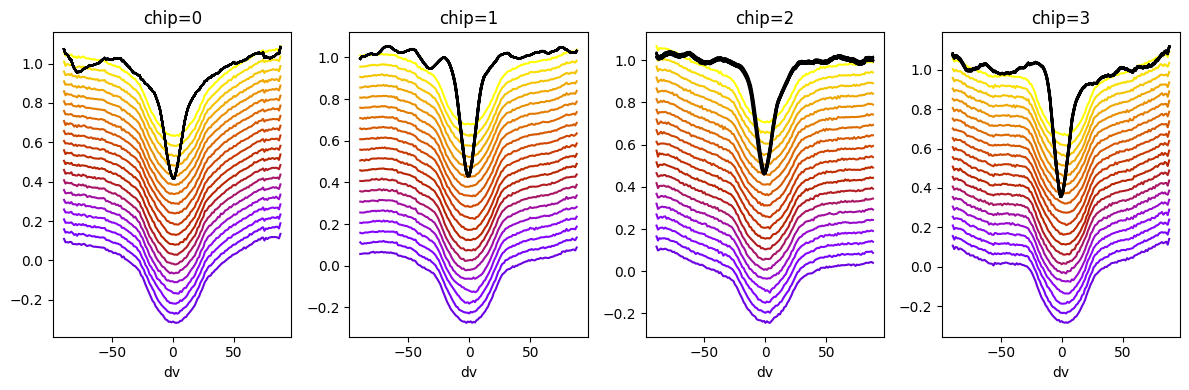

In [16]:
# Plot LSD kernels
gap=0.05
colors = [matplotlib.cm.gnuplot_r(x) for x in np.linspace(0, 1, nobs+4)]
plt.figure(figsize=(nchip*3,4))
for c in range(nchip):
    plt.subplot(1, nchip, c+1)
    for t in range(nobs):
        plt.plot(dv, 1 - kerns[t,c] - gap*t, color=colors[t])
        plt.plot(dv, 1 - modkerns[t,c], color='k')
    plt.title(f"chip={c}")
    plt.xlabel("dv")
plt.tight_layout()

In [17]:
# shift kerns to center
cen_modkerns = np.zeros_like(modkerns)
cen_kerns = np.zeros_like(kerns)
for i,c in enumerate(goodchips):
    modkerns_chip = np.median(modkerns[:,i,:], axis=0)
    systematic_rv_offset = (modkerns_chip==modkerns_chip.max()).nonzero()[0][0] - (dv==0).nonzero()[0][0] # find the rv offset
    print("chip:", c, "offset:", systematic_rv_offset)
    for k in range(nobs):
        cen_modkerns[k,i] = np.interp(np.arange(nk), np.arange(nk) - systematic_rv_offset, modkerns[k,i]) # shift ip to center at dv=0
        cen_kerns[k,i] = np.interp(np.arange(nk), np.arange(nk) - systematic_rv_offset, kerns[k,i]) # shift kerns with same amount

cen_kerns = np.copy(kerns)
cen_modkerns = np.copy(modkerns)

chip: 0 offset: 0
chip: 1 offset: -1
chip: 2 offset: -1
chip: 3 offset: -1


In [18]:
# contiuum-normalize kerns
obskerns = 1. - cen_kerns
obskerns_norm = np.zeros_like(obskerns)
continuumfit = np.zeros((nobs, nchip, 2))
side = 15
for c in range(nchip):
    for t in range(nobs):
        inds = np.concatenate((np.arange(0, side), np.arange(nk-side, nk)))
        continuumfit[t,c] = np.polyfit(inds, obskerns[t,c,inds], 1)
        obskerns_norm[t,c] = obskerns[t,c] / np.polyval(continuumfit[t,c], np.arange(nk))

intrinsic_profiles = np.array([modkerns[:,i].mean(0) for i in range(nchip)])

new nk: 110 (110,)


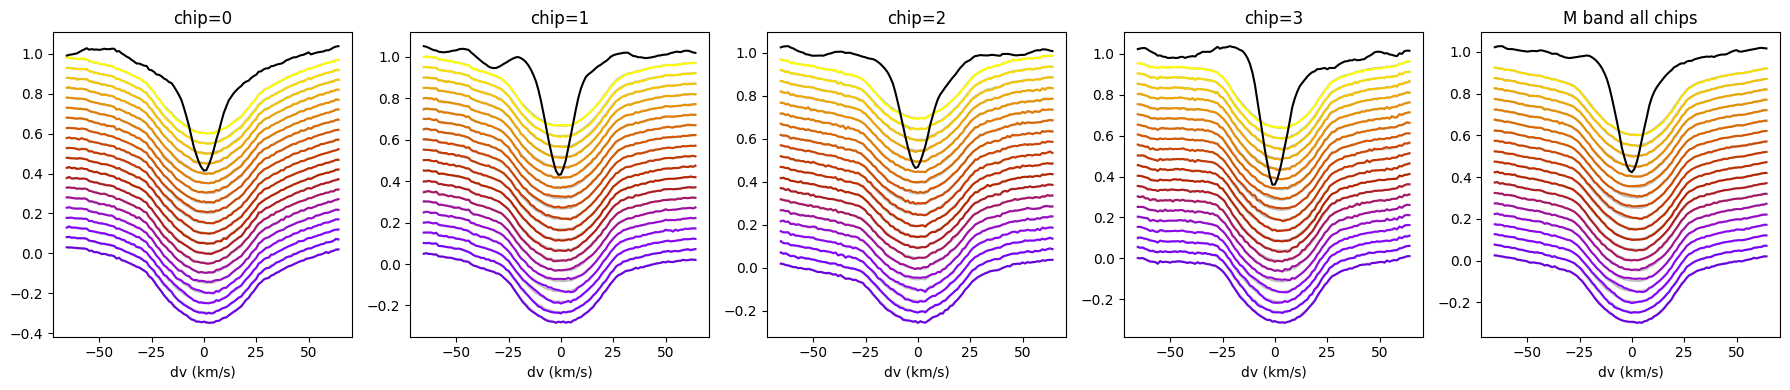

In [19]:
# cut out wings on the side
gap=0.05
s = 20
nk_cut = nk - s*2
dv_cut = dv[s:-s]
obskerns_cut = obskerns_norm[:,:,s:-s]
modkerns_cut = 1. - cen_modkerns[:,:,s:-s]
print("new nk:", nk_cut, dv_cut.shape)

plt.figure(figsize=(nchip*4.5,4))
for c in range(nchip):
    mean_obskerns = obskerns_cut[:,c].mean(0)
    mean_modkerns = modkerns_cut[:,c].mean(0)
    plt.subplot(1, nchip+1, c+1)
    for t in range(nobs):
        plt.plot(dv_cut, mean_obskerns - gap*t, color="grey", alpha=0.5)
        plt.plot(dv_cut, obskerns_cut[t,c] - gap*t, color=colors[t])
    plt.plot(dv_cut, mean_modkerns, color='k')
    plt.title(f"chip={c}")
    plt.xlabel("dv (km/s)")
plt.subplot(1, nchip+1, nchip+1)
for t in range(1,nobs):
    plt.plot(dv_cut, np.median(np.median(obskerns_cut,axis=0),axis=0) - gap*t, color="grey", alpha=0.5)
    plt.plot(dv_cut, np.median(obskerns_cut[t,:],axis=0) - gap*t, color=colors[t])
plt.plot(dv_cut, np.median(np.median(modkerns_cut,axis=0),axis=0), color='k')
plt.title(f"M band all chips")
plt.xlabel("dv (km/s)")
plt.tight_layout()

/var/folders/jm/dmx123p56254c5gy18wgtyh00000gn/T/ipykernel_21286/1475303964.py:23: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm,aspect=30, label="Elapsed time (h)")


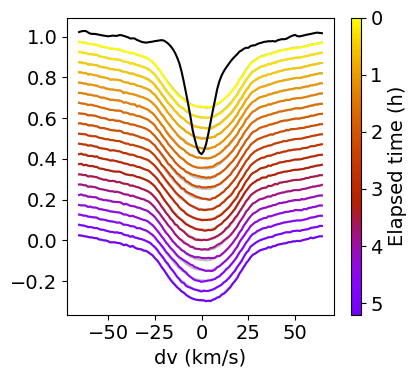

In [20]:
with plt.rc_context({
    'font.size': 14,
}):
    def truncate_cmap(cmap, minval=0.0, maxval=1.0, n=256):
        new_colors = cmap(np.linspace(minval, maxval, n))
        return matplotlib.colors.LinearSegmentedColormap.from_list(
            f"trunc({cmap.name},{minval:.2f},{maxval:.2f})", new_colors)
    cmap_trunc = truncate_cmap(matplotlib.cm.gnuplot_r, 0.0, 0.8)
    colors = [cmap_trunc(x) for x in np.linspace(0, 1, nobs)]

    gap = 0.05
    if target == "case3":
        gap = 0.05
    plt.figure(figsize=(4.5, 4))
    for t in range(0,nobs):
        plt.plot(dv_cut, np.median(np.median(obskerns_cut,axis=0),axis=0) - gap*t, color="grey", alpha=0.5)
        plt.plot(dv_cut, np.median(obskerns_cut[t,:],axis=0) - gap*t, color=colors[t])
    plt.plot(dv_cut, np.median(np.median(modkerns_cut,axis=0),axis=0), color='k', label='non-broadened model profile')
    #plt.title(f"M band all chips")
    norm = matplotlib.colors.Normalize(vmin=0, vmax=5.2)
    sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap_trunc)
    sm.set_array([])        # required by matplotlib
    cbar = plt.colorbar(sm,aspect=30, label="Elapsed time (h)")
    cbar.ax.invert_yaxis()
    cbar.set_ticks([0,1,2,3,4,5]) 
    #plt.legend(fontsize=9.4)
    plt.xlabel("dv (km/s)")
    plt.tight_layout()

/var/folders/jm/dmx123p56254c5gy18wgtyh00000gn/T/ipykernel_21286/952430681.py:30: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm,aspect=30, label="Elapsed time (h)")


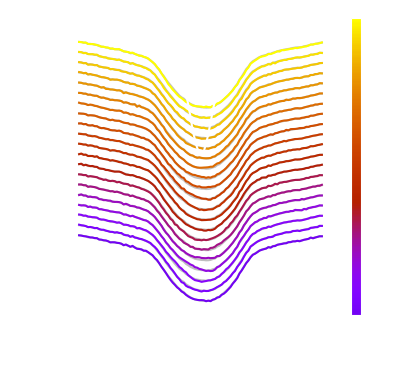

In [21]:
with plt.rc_context({
    'font.size': 14,
    'axes.facecolor': 'none',
    'figure.facecolor': 'none',
    'axes.edgecolor': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'text.color': 'white',
}):
    def truncate_cmap(cmap, minval=0.0, maxval=1.0, n=256):
        new_colors = cmap(np.linspace(minval, maxval, n))
        return matplotlib.colors.LinearSegmentedColormap.from_list(
            f"trunc({cmap.name},{minval:.2f},{maxval:.2f})", new_colors)
    cmap_trunc = truncate_cmap(matplotlib.cm.gnuplot_r, 0.0, 0.8)
    colors = [cmap_trunc(x) for x in np.linspace(0, 1, nobs)]

    gap = 0.05
    if target == "case3":
        gap = 0.05
    plt.figure(figsize=(4.5, 4))
    for t in range(0,nobs):
        plt.plot(dv_cut, np.median(np.median(obskerns_cut,axis=0),axis=0) - gap*t, color="grey", alpha=0.5)
        plt.plot(dv_cut, np.median(obskerns_cut[t,:],axis=0) - gap*t, color=colors[t])
    plt.plot(dv_cut, np.median(np.median(modkerns_cut,axis=0),axis=0), color='w', label='non-broadened model profile')
    #plt.title(f"M band all chips")
    norm = matplotlib.colors.Normalize(vmin=0, vmax=5.2)
    sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap_trunc)
    sm.set_array([])        # required by matplotlib
    cbar = plt.colorbar(sm,aspect=30, label="Elapsed time (h)")
    cbar.ax.invert_yaxis()
    cbar.set_ticks([0,1,2,3,4,5]) 
    #plt.legend(fontsize=9.4)
    plt.xlabel("dv (km/s)")
    plt.tight_layout()

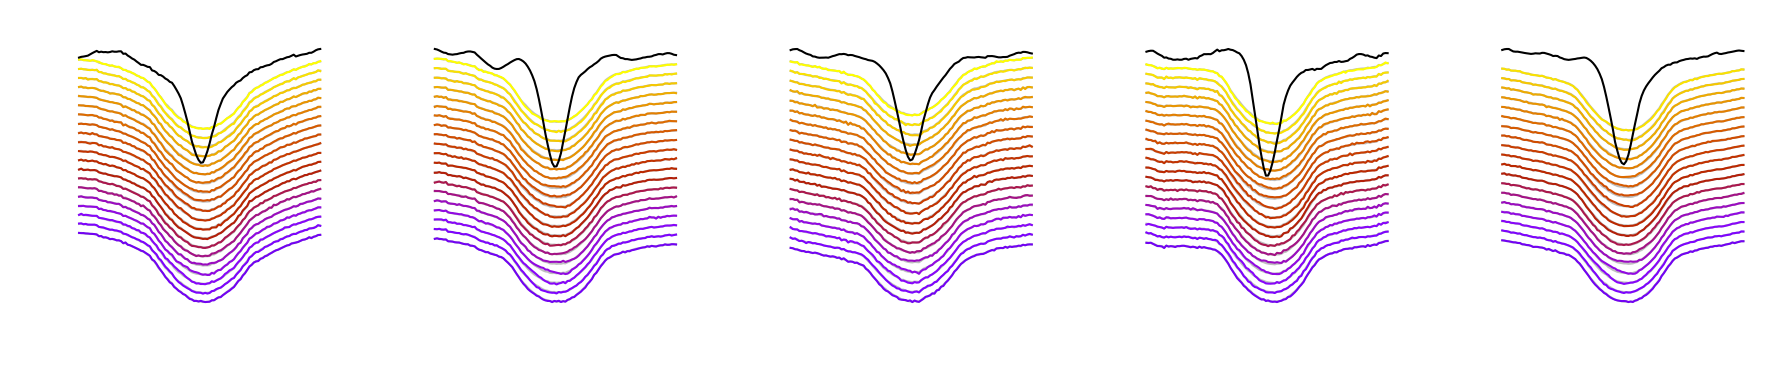

In [22]:
with plt.rc_context({
    'font.size': 14,
    'axes.facecolor': 'none',
    'figure.facecolor': 'none',
    'axes.edgecolor': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'text.color': 'white',
}):
    plt.figure(figsize=(nchip*4.5,4))
    for c in range(nchip):
        mean_obskerns = obskerns_cut[:,c].mean(0)
        mean_modkerns = modkerns_cut[:,c].mean(0)
        plt.subplot(1, nchip+1, c+1)
        for t in range(nobs):
            plt.plot(dv_cut, mean_obskerns - gap*t, color="grey", alpha=0.5)
            plt.plot(dv_cut, obskerns_cut[t,c] - gap*t, color=colors[t])
        plt.plot(dv_cut, mean_modkerns, color='k')
        plt.title(f"chip={c}")
        plt.xlabel("dv (km/s)")
    plt.subplot(1, nchip+1, nchip+1)
    for t in range(1,nobs):
        plt.plot(dv_cut, np.median(np.median(obskerns_cut,axis=0),axis=0) - gap*t, color="grey", alpha=0.5)
        plt.plot(dv_cut, np.median(obskerns_cut[t,:],axis=0) - gap*t, color=colors[t])
    plt.plot(dv_cut, np.median(np.median(modkerns_cut,axis=0),axis=0), color='k')
    plt.title(f"M band all chips")
    plt.xlabel("dv (km/s)")
    plt.tight_layout()

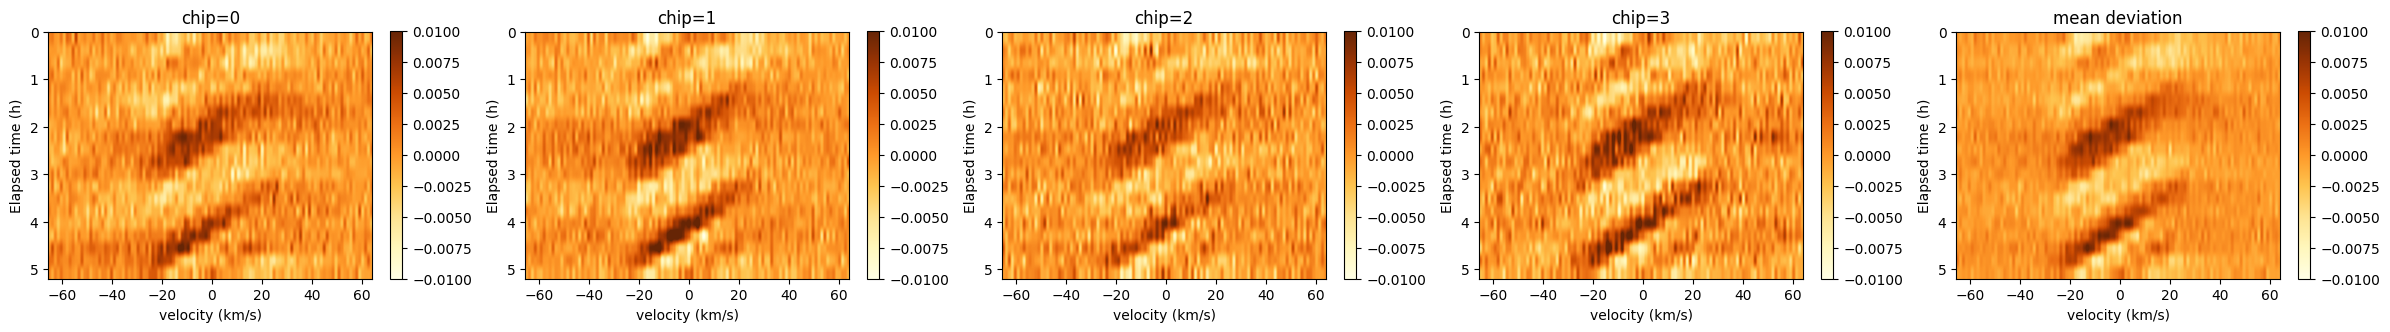

In [23]:
# deviation plot
period = 5.2
aspect = 0.9
vmax = 0.01
# store uniform profiles for each chip
uniform_profiles = np.zeros((nchip, nk_cut))

plt.figure(figsize=(nchip*6,4))
for i, c in enumerate(goodchips):
    uniform_profiles[i] = np.median(obskerns_cut[:,i], axis=0) # is each chip's mean kern over epoches
    plt.subplot(1,nchip+1,i+1)
    plt.imshow(obskerns_cut[:,i]-uniform_profiles[i], 
        extent=(dv_cut[0], dv_cut[-1], period, 0),
        aspect=int((nk_cut)/period*aspect),
        cmap='YlOrBr',
        vmax=vmax, vmin=-vmax) # positive diff means dark spot
    #plt.xlim(dv_cut.min(), dv_cut.max()),
    plt.xlabel("velocity (km/s)")
    plt.ylabel("Elapsed time (h)")
    plt.colorbar(fraction=0.035)
    plt.title(f"chip={c}")
# plot mean deviation
mean_dev = np.median(np.array([obskerns_cut[:,i]-uniform_profiles[i] for i in range(nchip)]), axis=0) # mean over chips
plt.subplot(1, nchip+1,i+2)
plt.imshow(mean_dev, 
    extent=(dv_cut[0], dv_cut[-1], period, 0),
    aspect=int((nk_cut)/period*aspect),
    cmap='YlOrBr',
    vmax=vmax, vmin=-vmax) # positive diff means dark spot
#plt.xlim(dv.min()+s, dv.max()-s),
plt.xlabel("velocity (km/s)")
plt.ylabel("Elapsed time (h)")
plt.colorbar(fraction=0.035)
plt.title(f"mean deviation")
plt.tight_layout()

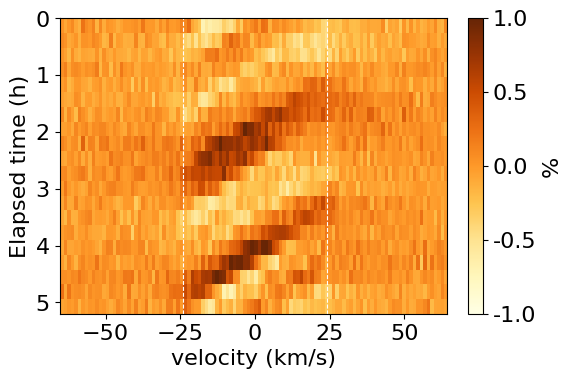

In [24]:
with plt.rc_context({
    'font.size': 16,
}):
    # deviation plot
    period = 5.2
    aspect = 0.9
    vmax = 0.01
    # store uniform profiles for each chip
    uniform_profiles = np.zeros((nchip, nk_cut))
    for i, c in enumerate(goodchips):
        uniform_profiles[i] = np.median(obskerns_cut[:,i], axis=0)

    # plot mean deviation
    mean_dev = np.median(np.array([obskerns_cut[:,i]-uniform_profiles[i] for i in range(nchip)]), axis=0) # mean over chips
    plt.figure(figsize=(6,5))
    plt.imshow(mean_dev, 
        extent=(dv_cut[0], dv_cut[-1], period, 0),
        aspect=int((nk_cut)/period*aspect),
        cmap='YlOrBr',
        vmax=vmax, vmin=-vmax) # positive diff means dark spot
    #plt.xlim(dv.min()+s, dv.max()-s),
    vsini=24
    plt.axvline(vsini, color='white', lw=0.8, ls='--')
    plt.axvline(-vsini, color='white', lw=0.8, ls='--')
    plt.xlabel("velocity (km/s)")
    plt.ylabel("Elapsed time (h)")
    plt.xticks([-50, -25, 0, 25, 50])
    cbar = plt.colorbar(fraction=0.035)
    cticks = np.array([-1.0, -0.5, 0, 0.5, 1.0])
    cbar.set_ticks(cticks/100, labels=cticks)
    cbar.set_label('%')
    #plt.title(f"mean deviation")
    plt.tight_layout()

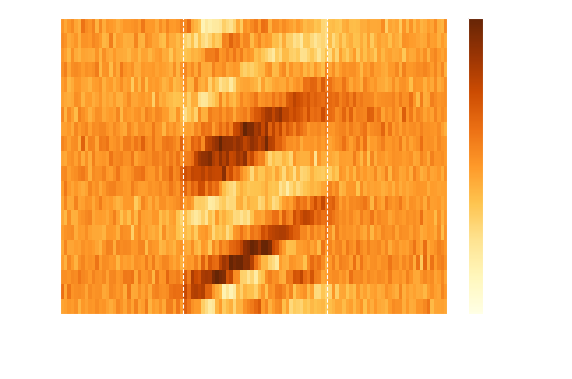

In [25]:
with plt.rc_context({
    'font.size': 16,
    'axes.facecolor': 'none',
    'figure.facecolor': 'none',
    'axes.edgecolor': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'text.color': 'white',
}):
    # deviation plot
    period = 5.2
    aspect = 0.9
    vmax = 0.01
    # store uniform profiles for each chip
    uniform_profiles = np.zeros((nchip, nk_cut))
    for i, c in enumerate(goodchips):
        uniform_profiles[i] = np.median(obskerns_cut[:,i], axis=0)

    # plot mean deviation
    mean_dev = np.median(np.array([obskerns_cut[:,i]-uniform_profiles[i] for i in range(nchip)]), axis=0) # mean over chips
    plt.figure(figsize=(6,5))
    plt.imshow(mean_dev, 
        extent=(dv_cut[0], dv_cut[-1], period, 0),
        aspect=int((nk_cut)/period*aspect),
        cmap='YlOrBr',
        vmax=vmax, vmin=-vmax) # positive diff means dark spot
    #plt.xlim(dv.min()+s, dv.max()-s),
    vsini=24
    plt.axvline(vsini, color='white', lw=0.8, ls='--')
    plt.axvline(-vsini, color='white', lw=0.8, ls='--')
    plt.xlabel("velocity (km/s)")
    plt.ylabel("Elapsed time (h)")
    plt.xticks([-50, -25, 0, 25, 50])
    cbar = plt.colorbar(fraction=0.035)
    cticks = np.array([-1.0, -0.5, 0, 0.5, 1.0])
    cbar.set_ticks(cticks/100, labels=cticks)
    cbar.set_label('%')
    #plt.title(f"mean deviation")
    plt.tight_layout()

In [26]:
from dime import DopplerImaging

In [27]:
period = 5.2
timestamps = np.array([0.000,
   0.278, 0.556, 0.833, 1.111, 1.389, 1.667, 1.944, 2.222,
   2.500, 2.778, 3.056, 3.333, 3.611, 3.889, 4.167, 4.444, 4.722,
   5.000, 5.278])
params_run = {
   'nk': 150, 
   'nobs': 20, 
   'timestamps': timestamps,
   'phases': 2*np.pi*timestamps/period,
   'inc': 80,
   'vsini': vsini, 
   'rv': 0, 
   'lld': 0.3, 
   'eqarea': True, 
   'nlat': 10, 
   'nlon': 20, 
   'alpha': 8000}

In [28]:
wav_nm = wav_angs / 10.0  # convert to nm
dmap = DopplerImaging(wav_nm, goodchips, params_dict=params_run, instru="METIS")
dmap.intrinsic_profiles = intrinsic_profiles
dmap.obskerns_norm = obskerns_norm
dmap.solve(create_obs_from_diff=True, solver='scipy')

nobs: 20, nchip: 4, npix: 4000
Created equa-area grid of 216 cells, in 12 latitude grids with [ 6 12 17 21 25 27 27 25 21 17 12  6] lontitude cells.
Rmatrix shape: (216, 3000)


/Users/xqchen/workspace/doppler-imaging-maxentropy/src/ELL_map_class.py:226: RuntimeWarning: divide by zero encountered in double_scalars
  np.sqrt(1. - np.tan(inc)**2 / np.tan(self.corners_latlon[0,ii])**2)
/Users/xqchen/workspace/doppler-imaging-maxentropy/src/ELL_map_class.py:226: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(1. - np.tan(inc)**2 / np.tan(self.corners_latlon[0,ii])**2)


Error of each observation (LSD profile): [0.00361836 0.00384741 0.00366741 0.00380127 0.00376974 0.00364714
 0.00362811 0.00356758 0.00375286 0.00383677 0.00364191 0.00366915
 0.00408513 0.00382232 0.00378636 0.00422997 0.00385739 0.00356614
 0.0038514  0.00380533]
metric: -42832.35, chisq: 319.95, entropy: 5.37


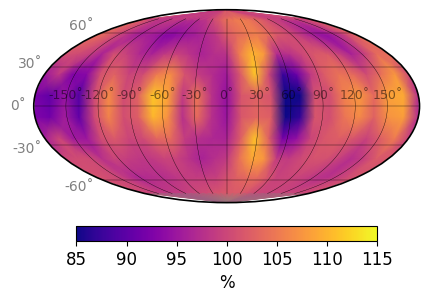

In [29]:
dmap.plot_mollweide_map(colorbar=True, vmin=85, vmax=115)

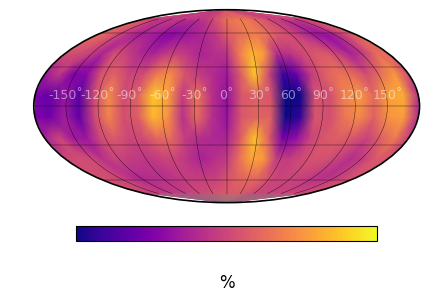

In [30]:
with plt.rc_context({
    'axes.facecolor': 'none',
    'figure.facecolor': 'none',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'text.color': 'white'
}):
    dmap.plot_mollweide_map(colorbar=True, vmin=85, vmax=115)

In [31]:
from scipy.signal import savgol_filter
hw=40
smoothed = savgol_filter(dmap.obskerns_norm, 31, 3)
resid = dmap.obskerns_norm - smoothed
err_pix = np.array([np.abs(resid[:,:,pix] - np.median(resid, axis=2)) for pix in range(nk)]) # error of each pixel in LP by MAD
if int(nk/2-hw) < 0:
    err_pix_linecen = err_pix
else:
    err_pix_linecen = err_pix[int(nk/2-hw):int(nk/2+hw)]
err_LP = 1.4826 * np.median(err_pix_linecen, axis=0) # error of each LP (at each t and chip)

signal = 1 - smoothed.min(axis=2).mean(axis=0) # signal = line depth
noise = np.median(err_LP, axis=0) # mean error of a chip
snr_LP = signal/noise # S/N of LP of each chip
snr_LP

array([105.68238915,  61.35189746,  62.21920988,  65.30462847])

In [38]:
dmap.bestmodel_2d

array([[1.        , 0.999259  , 1.00290875, ..., 1.00502241, 0.99973287,
        1.        ],
       [1.        , 1.00087345, 1.00145419, ..., 0.99962317, 0.99919362,
        1.        ],
       [1.        , 1.00112331, 1.00079509, ..., 1.00354364, 1.00237868,
        1.        ],
       ...,
       [1.        , 0.99896264, 1.00050277, ..., 1.00086137, 1.00123738,
        1.        ],
       [1.        , 1.00018043, 1.00200623, ..., 1.00237381, 0.99949654,
        1.        ],
       [1.        , 1.00321298, 1.00182794, ..., 0.99849119, 0.99907202,
        1.        ]])

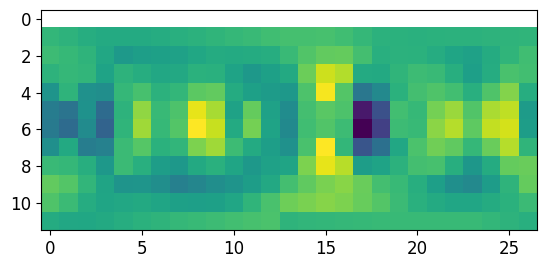

In [39]:
data = dmap.bestparamgrid  # (20, 150)
plt.imshow(data)

In [45]:
import cartopy.crs as ccrs
from matplotlib.animation import FuncAnimation
from PIL import Image

data = dmap.bestparamgrid  # (20, 150)
y, x = data.shape
inc = params_run['inc']

# --- upsample via bicubic, save, reload ---
fig = plt.figure(figsize=(10, 5))
plt.imshow(data, interpolation='bicubic', cmap='gray', aspect=x/y*0.5)
plt.axis('off')
fig.patch.set_visible(False)
plt.savefig("interpmap.png", bbox_inches='tight', dpi=200, pad_inches=0)
plt.close()

img = np.array(Image.open("interpmap.png").convert('L'), dtype='float64')
img[img == 255.] = np.nan   # white background -> NaN
img /= 255.                  # normalize to 0..1

# --- animate ---
cmap = plt.cm.plasma.copy()
cmap.set_bad(color="grey", alpha=1.0)

fig = plt.figure(figsize=(5, 5))

def update(frame):
    fig.clear()
    ax = fig.add_subplot(
        1, 1, 1,
        projection=ccrs.Orthographic(central_longitude=frame, central_latitude=90 - inc)
    )
    ax.set_global()
    ax.imshow(img, origin="lower", extent=(-180, 180, -90, 90),
              transform=ccrs.PlateCarree(), cmap=cmap, vmin=0., vmax=1.0)
    ax.gridlines(xlocs=range(-180, 180, 30), ylocs=range(-90, 90, 30),
                 color='gray', linewidth=0.3)
    
    num_frames = len(frames)
    t = frame / 360 * period          # hours elapsed this rotation
    ax.text(0.85, 0.05, f'{t:.1f}h', transform=ax.transAxes)

    return []

frames = np.arange(0, 360, 4)
anim = FuncAnimation(fig, update, frames=frames, blit=False)
anim.save("metis_sim_1049b.gif", writer="pillow", fps=20)
plt.close()